In [4]:
# ==========================
# 1. 导入库
# ==========================
from pathlib import Path
import geopandas as gpd
import xarray as xr
import rioxarray
import rasterio
import matplotlib.pyplot as plt
# ==========================
# 2. 项目路径（以后只改这里）
# ==========================
PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data2" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data2" / "processed"
OUTPUT_DIR = PROJECT_DIR / "data2" / "outputs"

print(PROJECT_DIR)
print(RAW_DIR)
print(PROCESSED_DIR)

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction
/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw
/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/processed


In [5]:
import sys

!{sys.executable} -m pip install fiona pyogrio geopandas shapely


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [6]:
import os
print(os.listdir("/Users/wangjingxuan"))

['Untitled10.ipynb', '.Rhistory', 'Untitled7.ipynb', '.config', 'Music', '.condarc', 'print("A").py', '.copilot', 'Untitled5.ipynb', 'datamodeler.log.1', 'Untitled1.ipynb', '.DS_Store', 'Kaggle', '1.R', '.vscode-shared', 'datamodeler.log', '.CFUserTextEncoding', '.xonshrc', 'Untitled3.ipynb', 'Untitled.ipynb', 'FIT9137_w6_wireshark.pcap', 'untitled.md', '.zshrc', 'Jingxuan_Wang', 'Untitled4.ipynb', '.local', 'countdown.pyopen', 'Untitled6.ipynb', 'Pictures', 'Untitled11.ipynb', '.zprofile', '.oraclesqldeveloperdatamodeler', 'test.imnls', '.zsh_history', 'Untitled2.ipynb', '.ipython', 'Desktop', 'Library', '.matplotlib', 'Monash', '.sqlcl', '.lesshst', 'test.imn', '.RDataTmp1', 'untitled1.md', 'FIT5145', 'untitled.txt', 'test.imnls.save', 'PycharmProjects', 'Public', 'XGBoot.ipynb', '.idlerc', 'untitled.r', 'untitled1.txt', '.tcshrc', '-e', '.RData', 'untitled1.r', '.anaconda', 'untitled2.txt', 'Untitled8.ipynb', 'Movies', 'Applications', '.Rapp.history', '.Trash', 'IdeaProjects', '.ipy

In [7]:
import os

os.listdir("/Users/wangjingxuan/Jingxuan Wang")

['WA-Soil-Salinity-Prediction']

In [8]:
import sys
print(sys.executable)

/Users/wangjingxuan/Jingxuan_Wang/.venv/bin/python


In [9]:
import os

base = "/Users/wangjingxuan/Jingxuan Wang"

for f in os.listdir(base):
    print(f)

WA-Soil-Salinity-Prediction


In [10]:
import os

project = "/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction"

for f in os.listdir(project):
    print(f)

.DS_Store
README.md
data2
notebooks


In [11]:
import os

for root, dirs, files in os.walk("/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction"):
    for f in files:
        if f.endswith(".shp") or f.endswith(".gpkg"):
            print(os.path.join(root, f))

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/processed/salinity_wheatbelt.gpkg
/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg
/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg


In [12]:
from pathlib import Path

raw = Path.cwd().parent / "data2" / "raw"

for f in raw.glob("*Wheatbelt*"):
    print(f)

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg


In [13]:
import fiona

fiona.listlayers(
    "/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg"
)

['Wheatbelt_of_WA_DPIRD_024']

In [14]:
import geopandas as gpd

wheatbelt = gpd.read_file(
    "/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg",
    layer="Wheatbelt_of_WA_DPIRD_024"
)

print(wheatbelt.crs)

EPSG:7844


In [15]:
import sys

print(sys.executable)

/Users/wangjingxuan/Jingxuan_Wang/.venv/bin/python


In [16]:
import geopandas as gpd
import fiona

print("GIS environment ready")

GIS environment ready


In [17]:
import geopandas as gpd

gdf = gpd.read_file(
    "/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg",
    layer="Surface_Salinity_current_DPIRD_039"
)

print(gdf.head())
print(gdf.crs)

  surf_sa_co                                             decode     id  \
0         L1  <3% of map unit has a moderate to extreme surf...  34305   
1         L1  <3% of map unit has a moderate to extreme surf...  37335   
2         L1  <3% of map unit has a moderate to extreme surf...  37336   
3         L1  <3% of map unit has a moderate to extreme surf...  34101   
4         L1  <3% of map unit has a moderate to extreme surf...  37085   

   st_area_shape_  st_perimeter_shape_  \
0    4.604105e-06             0.009845   
1    5.788251e-08             0.000981   
2    5.788055e-08             0.000981   
3    7.522192e-04             0.236480   
4    1.209817e-07             0.001315   

                                            geometry  
0  MULTIPOLYGON (((116.81214 -32.47417, 116.8128 ...  
1  MULTIPOLYGON (((116.77972 -32.40753, 116.77967...  
2  MULTIPOLYGON (((116.77954 -32.40396, 116.77949...  
3  MULTIPOLYGON (((116.77783 -32.44976, 116.77768...  
4  MULTIPOLYGON (((116.7844

In [18]:
gdf = gdf.to_crs(3857)

gdf["area_km2"] = gdf.geometry.area / 1e6

area_summary = (
    gdf.groupby("surf_sa_co")["area_km2"]
       .sum()
       .reset_index()
       .sort_values("area_km2", ascending=False)
)

area_summary

,surf_sa_co,area_km2
2,L1,253986.663105
3,L2,61667.921146
4,M1,19661.824435
1,H2,8041.432355
0,H1,4826.825591
5,M2,4696.767481


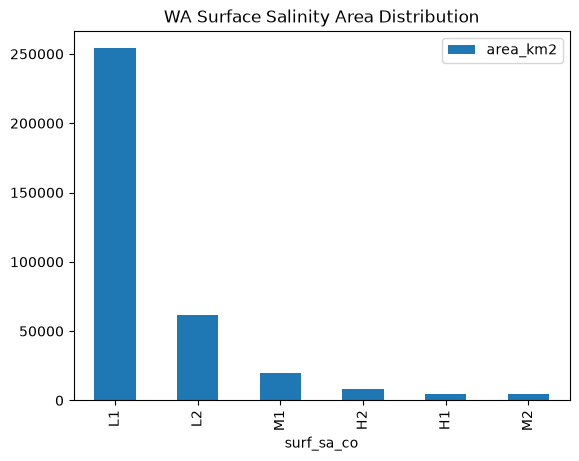

In [19]:
import matplotlib.pyplot as plt

area_summary.plot(
    x="surf_sa_co",
    y="area_km2",
    kind="bar"
)

plt.title("WA Surface Salinity Area Distribution")
plt.show()

In [20]:
import fiona

fiona.listlayers(path)

NameError: name 'path' is not defined

In [21]:
import fiona

fiona.listlayers(
    "../data2/raw/Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg"
)

['Surface_Salinity_current_DPIRD_039']

In [22]:
import geopandas as gpd

salinity = gpd.read_file(
    "../data2/raw/Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg",
    layer="Surface_Salinity_current_DPIRD_039"
)

wheatbelt = gpd.read_file(
    "../data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg",
    layer="Wheatbelt_of_WA_DPIRD_024"
)

print(salinity.crs)
print(wheatbelt.crs)

EPSG:7844
EPSG:7844


In [23]:
import os

print(os.listdir("/Users/wangjingxuan/Jingxuan Wang"))

['WA-Soil-Salinity-Prediction']


In [24]:
import os

print(os.listdir(
"/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw"
))

['cop30_wheatbelt.tif', 'output_AW3D30.tif', '.DS_Store', 'output_hh 2.tif', 'output_hh.tif', 'Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg', '2020.monthly_rain.nc', 'Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg']


In [25]:
print(os.path.exists(
"/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg"
))

True


In [26]:
from pathlib import Path
import geopandas as gpd

# =====================================================
# Project paths
# =====================================================
# 当前 Notebook 位于：
# WA-Soil-Salinity-Prediction/notebooks/
PROJECT_DIR = Path.cwd().parent

RAW_DIR = PROJECT_DIR / "data2" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data2" / "processed"
OUTPUT_DIR = PROJECT_DIR / "data2" / "outputs"

print("Project:", PROJECT_DIR)
print("Raw:", RAW_DIR)
print("Processed:", PROCESSED_DIR)
print("Output:", OUTPUT_DIR)

# =====================================================
# Read Surface Salinity
# =====================================================
salinity = gpd.read_file(
    RAW_DIR / "Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg",
    layer="Surface_Salinity_current_DPIRD_039"
)

# =====================================================
# Read Wheatbelt boundary
# =====================================================
wheatbelt = gpd.read_file(
    RAW_DIR / "Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg",
    layer="Wheatbelt_of_WA_DPIRD_024"
)

print("\nSurface Salinity CRS:", salinity.crs)
print("Wheatbelt CRS:", wheatbelt.crs)

print("\nSurface Salinity:")
display(salinity.head())

print("\nWheatbelt:")
display(wheatbelt.head())

Project: /Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction
Raw: /Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw
Processed: /Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/processed
Output: /Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/outputs

Surface Salinity CRS: EPSG:7844
Wheatbelt CRS: EPSG:7844

Surface Salinity:


,surf_sa_co,decode,id,st_area_shape_,st_perimeter_shape_,geometry
0,L1,<3% of map unit has a moderate to extreme surf...,34305,4.604105e-06,0.009845,"MULTIPOLYGON (((116.81214 -32.47417, 116.8128 ..."
1,L1,<3% of map unit has a moderate to extreme surf...,37335,5.788251e-08,0.000981,"MULTIPOLYGON (((116.77972 -32.40753, 116.77967..."
2,L1,<3% of map unit has a moderate to extreme surf...,37336,5.788055e-08,0.000981,"MULTIPOLYGON (((116.77954 -32.40396, 116.77949..."
3,L1,<3% of map unit has a moderate to extreme surf...,34101,7.522192e-04,0.236480,"MULTIPOLYGON (((116.77783 -32.44976, 116.77768..."
4,L1,<3% of map unit has a moderate to extreme surf...,37085,1.209817e-07,0.001315,"MULTIPOLYGON (((116.78443 -32.40379, 116.78445..."



Wheatbelt:


,id1,st_area_shape_,st_perimeter_shape_,object_id,geometry
0,6,6.621379e+06,11705.385729,1,"POLYGON ((114.58952 -27.52349, 114.60677 -27.5..."
1,7,5.132524e+06,10751.855434,2,"POLYGON ((114.6274 -27.56202, 114.63857 -27.57..."
2,8,2.665443e+07,22446.030023,3,"POLYGON ((114.69383 -27.52451, 114.71014 -27.5..."
3,10,1.584373e+08,79455.154925,4,"POLYGON ((115.30617 -27.83164, 115.30593 -27.8..."
4,12,1.688710e+04,1020.385641,5,"POLYGON ((114.60952 -28.7659, 114.60962 -28.76..."


In [27]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent

DATA_DIR = PROJECT_DIR / "data2" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data2" / "processed"
OUTPUT_DIR = PROJECT_DIR / "data2" / "outputs"

In [28]:
import os

print(PROJECT_DIR)
print(DATA_DIR)

print(os.listdir(DATA_DIR))

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction
/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw
['cop30_wheatbelt.tif', 'output_AW3D30.tif', '.DS_Store', 'output_hh 2.tif', 'output_hh.tif', 'Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg', '2020.monthly_rain.nc', 'Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg']


In [29]:
import geopandas as gpd

salinity = gpd.read_file(
    DATA_DIR / "Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg"
)

wheatbelt = gpd.read_file(
    DATA_DIR / "Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg"
)

print(salinity.head())
print(wheatbelt.head())

  surf_sa_co                                             decode     id  \
0         L1  <3% of map unit has a moderate to extreme surf...  34305   
1         L1  <3% of map unit has a moderate to extreme surf...  37335   
2         L1  <3% of map unit has a moderate to extreme surf...  37336   
3         L1  <3% of map unit has a moderate to extreme surf...  34101   
4         L1  <3% of map unit has a moderate to extreme surf...  37085   

   st_area_shape_  st_perimeter_shape_  \
0    4.604105e-06             0.009845   
1    5.788251e-08             0.000981   
2    5.788055e-08             0.000981   
3    7.522192e-04             0.236480   
4    1.209817e-07             0.001315   

                                            geometry  
0  MULTIPOLYGON (((116.81214 -32.47417, 116.8128 ...  
1  MULTIPOLYGON (((116.77972 -32.40753, 116.77967...  
2  MULTIPOLYGON (((116.77954 -32.40396, 116.77949...  
3  MULTIPOLYGON (((116.77783 -32.44976, 116.77768...  
4  MULTIPOLYGON (((116.7844

In [30]:
# GIS 分析
# 检查坐标系
print(salinity.crs)
print(wheatbelt.crs)

EPSG:7844
EPSG:7844


7


<Axes: >

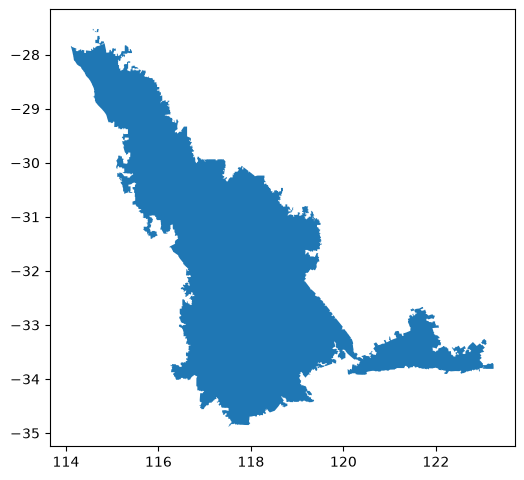

In [31]:
# Wheatbelt 数据里有多少条记录（Feature）
# 输出7 个 Polygon
print(len(wheatbelt))

# wheatbelt.plot(figsize=(6,6))
wheatbelt.plot(figsize=(6,6))


In [32]:
#确认坐标系
print(salinity.crs)
print(wheatbelt.crs)

EPSG:7844
EPSG:7844


In [33]:
# 裁剪（Clip)
salinity_wheatbelt = gpd.clip(
    salinity,
    wheatbelt
)

# 裁剪之后原来整个 WA 有 14725 个盐碱化 Polygon，现在 Wheatbelt 只剩 3620 个
print(len(salinity))
print(len(salinity_wheatbelt))

14725
11818


<Axes: >

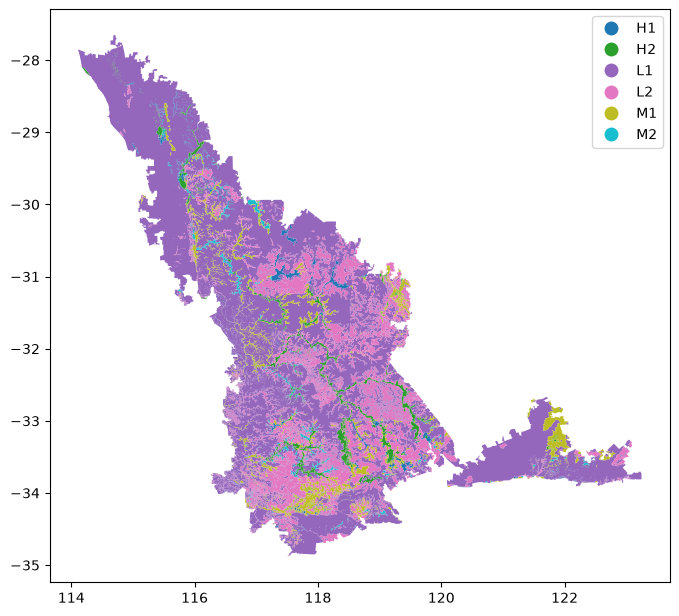

In [34]:
# 画图
salinity_wheatbelt.plot(
    column="surf_sa_co",
    legend=True,
    figsize=(8,8)
)

In [35]:
# Exploratory Data Analysis
# 看看数据有多少条
print(len(salinity_wheatbelt))
# 看看六个类别分别有多少
salinity_wheatbelt["surf_sa_co"].value_counts()

11818


surf_sa_co
L1    4968
L2    3083
H1    1279
H2    1062
M1     881
M2     545
Name: count, dtype: int64

<Axes: xlabel='surf_sa_co'>

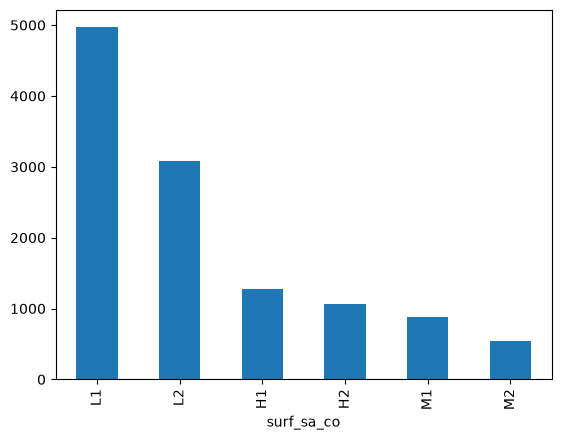

In [36]:
# 看面积， 再画一张统计图
salinity_wheatbelt["st_area_shape_"].describe()
salinity_wheatbelt["surf_sa_co"].value_counts().plot.bar()

In [37]:
salinity_wheatbelt.to_file(
    PROCESSED_DIR / "salinity_wheatbelt.gpkg",
    driver="GPKG"
)

In [38]:
#数据探索
#数据基本信息
print(salinity_wheatbelt.shape)
salinity_wheatbelt.info()

(11818, 6)
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 11818 entries, 4320 to 13654
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   surf_sa_co           11818 non-null  str     
 1   decode               11818 non-null  str     
 2   id                   11818 non-null  int32   
 3   st_area_shape_       11818 non-null  float64 
 4   st_perimeter_shape_  11818 non-null  float64 
 5   geometry             11818 non-null  geometry
dtypes: float64(2), geometry(1), int32(1), str(2)
memory usage: 600.1 KB


In [39]:
#类别分布
salinity_wheatbelt["surf_sa_co"].value_counts()

surf_sa_co
L1    4968
L2    3083
H1    1279
H2    1062
M1     881
M2     545
Name: count, dtype: int64

<Axes: xlabel='surf_sa_co'>

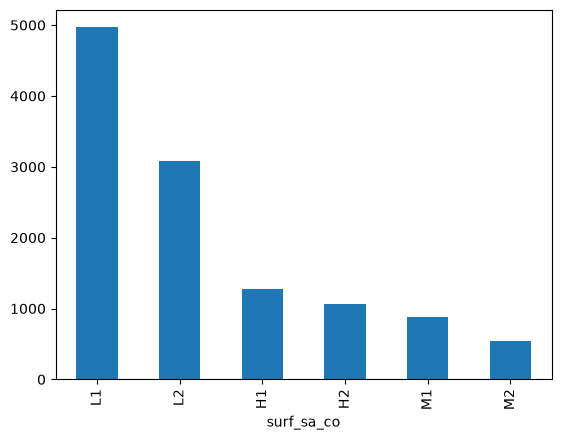

In [40]:
# 画图
salinity_wheatbelt["surf_sa_co"].value_counts().plot.bar()

In [41]:
salinity_wheatbelt["st_area_shape_"].describe()

count    1.181800e+04
mean     1.998083e-03
std      1.140560e-01
min      6.648560e-09
25%      5.763182e-06
50%      2.951920e-05
75%      1.517272e-04
max      1.226213e+01
Name: st_area_shape_, dtype: float64

In [42]:
import os



print(os.path.exists("../data2/raw/output_AW3D30.tif"))
%pip install rasterio
import rasterio

dem = rasterio.open("../data2/raw/output_AW3D30.tif")

print(dem)

True

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
<open DatasetReader name='../data2/raw/output_AW3D30.tif' mode='r'>


In [43]:
#查看 DEM 基本信息
print("宽度:", dem.width)
print("高度:", dem.height)
print("波段数:", dem.count)
print("坐标系:", dem.crs)
print("范围:", dem.bounds)

宽度: 5470
高度: 4061
波段数: 1
坐标系: EPSG:4326
范围: BoundingBox(left=119.93138888893122, bottom=30.85833333332577, right=121.45083333337588, top=31.986388888881486)


In [44]:
#查看高程值
elevation = dem.read(1)

print(elevation.shape)
print(elevation.min())
print(elevation.max())

(4061, 5470)
-77
520


/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_1248/1103529560.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  elevation = dem.read(1)


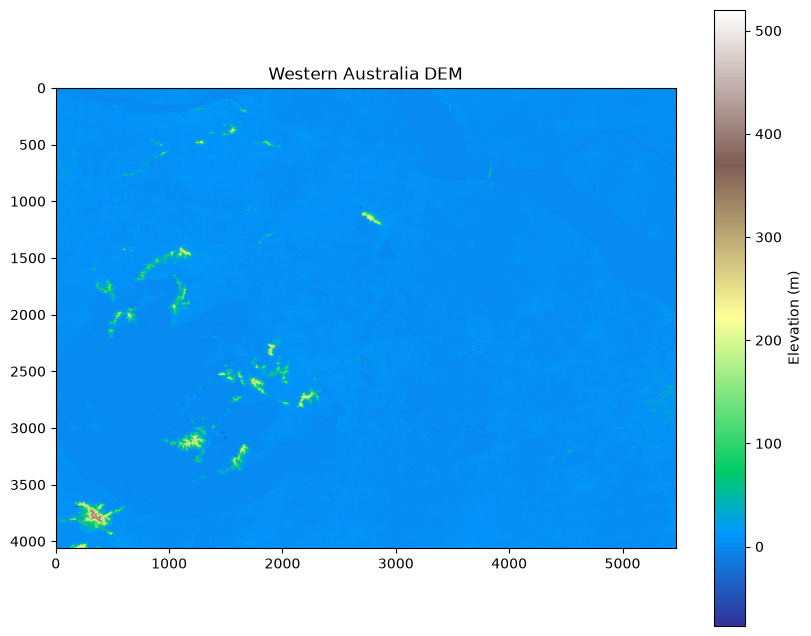

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(elevation, cmap="terrain")

plt.colorbar(label="Elevation (m)")

plt.title("Western Australia DEM")

plt.show()

In [46]:
# 直接用 rasterio + numpy 计算 Slope
# 读取 DEM
import rasterio
import numpy as np
import matplotlib.pyplot as plt

with rasterio.open("../data2/processed/cop30_utm50s.tif") as src:
    dem = src.read(1).astype(float)
    transform = src.transform

/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_1248/3138550399.py:8: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = src.read(1).astype(float)


In [47]:
# 检查 DEM
src = rasterio.open("../data2/processed/cop30_utm50s.tif")
print("CRS:", src.crs)
print("Resolution:", src.res)
print("Bounds:", src.bounds)
print(src.transform)

CRS: EPSG:32750
Resolution: (28.431199796308288, 28.431199796308288)
Bounds: BoundingBox(left=253009.1606663636, bottom=6110493.424922038, right=1093236.4082466625, top=6958198.078048766)
| 28.43, 0.00, 253009.16|
| 0.00,-28.43, 6958198.08|
| 0.00, 0.00, 1.00|


In [48]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
import rasterio
src_path = "../data2/raw/cop30_wheatbelt.tif"
dst_path = "../data2/processed/cop30 utm50s.tif"

with rasterio.open(src_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs,
        "EPSG:32750",
        src.width,
        src.height,
        *src.bounds
    )

    profile = src.profile.copy()
    profile.update({
        "crs": "EPSG:32750",
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(dst_path, "w", **profile) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs="EPSG:32750",
                resampling=Resampling.bilinear
            )

print("Done!")
print("New transform:")
print(transform)
print("New width:", width)
print("New height:", height)

Done!
New transform:
| 28.43, 0.00, 253009.16|
| 0.00,-28.43, 6958198.08|
| 0.00, 0.00, 1.00|
New width: 29553
New height: 29816


In [49]:
src = rasterio.open("../data2/processed/output_AW3D30_utm50s.tif")

print(src.crs)
print(src.res)

EPSG:32750
(28.080605528149828, 28.080605528149828)


In [50]:
import numpy as np

dem = src.read(1).astype(float)

cellsize_x, cellsize_y = src.res

dz_dy, dz_dx = np.gradient(dem, cellsize_y, cellsize_x)

slope = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))

/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_1248/282179666.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = src.read(1).astype(float)


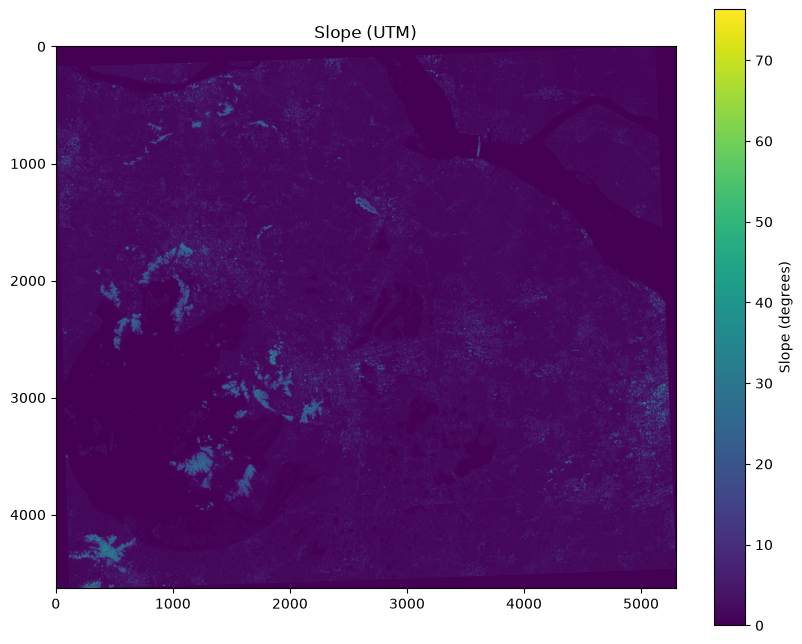

Slope saved!


In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(slope, cmap="viridis")

plt.colorbar(label="Slope (degrees)")

plt.title("Slope (UTM)")

plt.show()
with rasterio.open("../data2/processed/cop30_utm50s.tif") as dem_src:
    profile = dem_src.profile.copy()

profile.update(
    dtype=rasterio.float32,
    count=1
)

with rasterio.open(
    "../data2/processed/slope_cop30.tif",
    "w",
    **profile
) as dst:
    dst.write(slope.astype(rasterio.float32), 1)

print("Slope saved!")

In [52]:
import rasterio

with rasterio.open("../data2/processed/cop30_utm50s.tif") as src:
    profile = src.profile.copy()

profile.update(
    dtype=rasterio.float32,
    count=1
)

with rasterio.open(
    "../data2/processed/slope_cop30.tif",
    "w",
    **profile
) as dst:

    dst.write(slope.astype(rasterio.float32), 1)

In [53]:
import sys
print(sys.executable)

/Users/wangjingxuan/Jingxuan_Wang/.venv/bin/python


In [54]:
import geopandas as gpd
import xarray as xr
import rioxarray
import rasterio

print("All packages imported successfully!")

All packages imported successfully!


In [55]:
#读取降雨数据
import xarray as xr

rain = xr.open_dataset("../data2/raw/2020.monthly_rain.nc")

In [56]:
# 计算全年降雨
annual_rain = rain["monthly_rain"].sum(dim="time")

In [61]:
import rioxarray

dem = rioxarray.open_rasterio(
    "../data2/processed/cop30_utm50s.tif"
).squeeze()

print(type(dem))
print(dem.rio.crs)

<class 'xarray.core.dataarray.DataArray'>
EPSG:32750


In [62]:
import rioxarray

# 计算全年降雨
annual_rain = rain["monthly_rain"].sum(dim="time")

# 指定空间维度
annual_rain = annual_rain.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat"
)

# 写入 CRS（原始 nc 文件是 WGS84）
annual_rain = annual_rain.rio.write_crs("EPSG:4326")

# 重投影到 DEM
annual_rain_proj = annual_rain.rio.reproject_match(dem)

print(annual_rain_proj)

<xarray.DataArray 'monthly_rain' (y: 29816, x: 29553)> Size: 7GB
array([[250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       ...,
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ]],
      shape=(29816, 29553))
Coordinates:
  * y            (y) float64 239kB 6.958e+06 6.958e+06 ... 6.111e+06 6.111e+06
  * x            (x) float64 236kB 2.53e+05 2.531e+05 ... 1.093e+06 1.093e+06
    spatial_ref  int64 8B 0
Attributes:
    long_name:   Monthly rainfall
    units:       mm
    valid_min:   -32765
    valid_max:   32767
    _FillValue:  nan


In [64]:
print(type(annual_rain))
print(annual_rain.rio.crs)

<class 'xarray.core.dataarray.DataArray'>
EPSG:4326


In [65]:
annual_rain_proj = annual_rain.rio.reproject_match(dem)

In [66]:
print(type(dem))

<class 'xarray.core.dataarray.DataArray'>


In [67]:

print(annual_rain_proj.shape)
print(annual_rain_proj.rio.bounds())
print(annual_rain_proj.min().item())
print(annual_rain_proj.max().item())

(29816, 29553)
(253009.1606663636, 6110493.424922038, 1093236.4082466625, 6958198.078048766)
0.0
1412.799999999997


In [68]:
# 读取 Wheatbelt
import geopandas as gpd

wheatbelt = gpd.read_file(
    "../data2/raw/Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg"
)

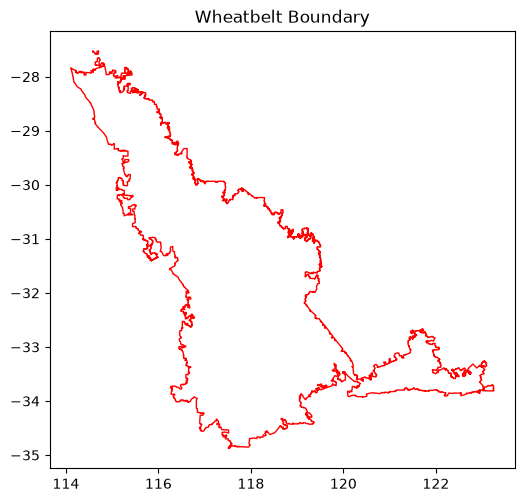

In [69]:
#画Wheltbelt边界
fig, ax = plt.subplots(figsize=(6, 6))

wheatbelt.plot(
    ax=ax,
    edgecolor="red",
    facecolor="none"
)

ax.set_title("Wheatbelt Boundary")

plt.show()

In [70]:
import rioxarray
import xarray as xr

rain = xr.open_dataset("../data2/raw/2020.monthly_rain.nc")
print(rain)
list(rain.data_vars)

<xarray.Dataset> Size: 55MB
Dimensions:       (time: 12, lat: 681, lon: 841)
Coordinates:
  * time          (time) datetime64[ns] 96B 2020-01-16T12:00:00 ... 2020-12-1...
  * lat           (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon           (lon) float64 7kB 112.0 112.0 112.1 ... 153.9 153.9 154.0
Data variables:
    monthly_rain  (time, lat, lon) float64 55MB ...
    crs           |S1 1B ...
Attributes:
    department:               Department of Environment and Science
    department_short:         DES
    copyright:                Copyright - the State of Queensland Department ...
    site_url:                 http://www.longpaddock.qld.gov.au
    institution:              Queensland Government, Department of Environmen...
    raster_source:            Gridded surface was created by interpolating ob...
    raster_source_additions:  and other suppliers (see the SILO webpage for d...
    metadata_url:             http://qldspatial.information.qld.gov.au/catal

['monthly_rain', 'crs']

In [71]:
# 检查降雨数据的CRS
rain.rio.crs
rain = rain.rio.write_crs("EPSG:4326")
rain.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [72]:
# 提取降雨变量
rain_da = rain["monthly_rain"]

rain_da

<xarray.DataArray 'monthly_rain' (time: 12, lat: 681, lon: 841)> Size: 55MB
[6872652 values with dtype=float64]
Coordinates:
  * time         (time) datetime64[ns] 96B 2020-01-16T12:00:00 ... 2020-12-16...
  * lat          (lat) float64 5kB -44.0 -43.95 -43.9 ... -10.1 -10.05 -10.0
  * lon          (lon) float64 7kB 112.0 112.0 112.1 112.2 ... 153.9 153.9 154.0
    spatial_ref  int64 8B 0
Attributes:
    long_name:  Monthly rainfall
    units:      mm
    valid_min:  -32765
    valid_max:  32767

In [73]:
# 指定空间维度
annual_rain = annual_rain.rio.set_spatial_dims(
    x_dim="lon",
    y_dim="lat"
)
annual_rain.rio.crs

annual_rain = annual_rain.rio.write_crs("EPSG:4326")
print(annual_rain.rio.crs)

EPSG:4326


In [74]:
dem = rioxarray.open_rasterio(
    "../data2/processed/cop30_utm50s.tif"
)
dem = dem.squeeze()
print(dem.rio.shape)

(29816, 29553)


In [75]:
# 重投影到 Wheatbelt 的 CRS
wheatbelt = wheatbelt.to_crs("EPSG:32750")
annual_rain_proj = annual_rain.rio.reproject_match(dem)

print(annual_rain_proj)

<xarray.DataArray 'monthly_rain' (y: 29816, x: 29553)> Size: 7GB
array([[250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       ...,
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ]],
      shape=(29816, 29553))
Coordinates:
  * y            (y) float64 239kB 6.958e+06 6.958e+06 ... 6.111e+06 6.111e+06
  * x            (x) float64 236kB 2.53e+05 2.531e+05 ... 1.093e+06 1.093e+06
    spatial_ref  int64 8B 0
Attributes:
    long_name:   Monthly rainfall
    units:       mm
    valid_min:   -32765
    valid_max:   32767
    _FillValue:  nan


In [76]:
print(dem.rio.crs)
print(dem.rio.shape)
print(dem.rio.bounds())

EPSG:32750
(29816, 29553)
(253009.1606663636, 6110493.424922038, 1093236.4082466625, 6958198.078048766)


In [79]:
# 裁剪 Wheatbelt
from rioxarray.exceptions import NoDataInBounds

rain_clip = annual_rain_proj.rio.clip(
    wheatbelt.geometry,
    wheatbelt.crs,
    drop=True
)

print(rain_clip)

<xarray.DataArray 'monthly_rain' (y: 28595, x: 29057)> Size: 7GB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(28595, 29057))
Coordinates:
  * y            (y) float64 229kB 6.953e+06 6.953e+06 ... 6.14e+06 6.14e+06
  * x            (x) float64 232kB 2.53e+05 2.531e+05 ... 1.079e+06 1.079e+06
    spatial_ref  int64 8B 0
Attributes:
    long_name:   Monthly rainfall
    units:       mm
    valid_min:   -32765
    valid_max:   32767
    _FillValue:  nan


In [81]:
print(np.isnan(rain_clip.values).sum())
print(rain_clip.size)
print(rain_clip.min().item())
print(rain_clip.max().item())

595341630
830884915
168.39999999999782
917.2999999999979


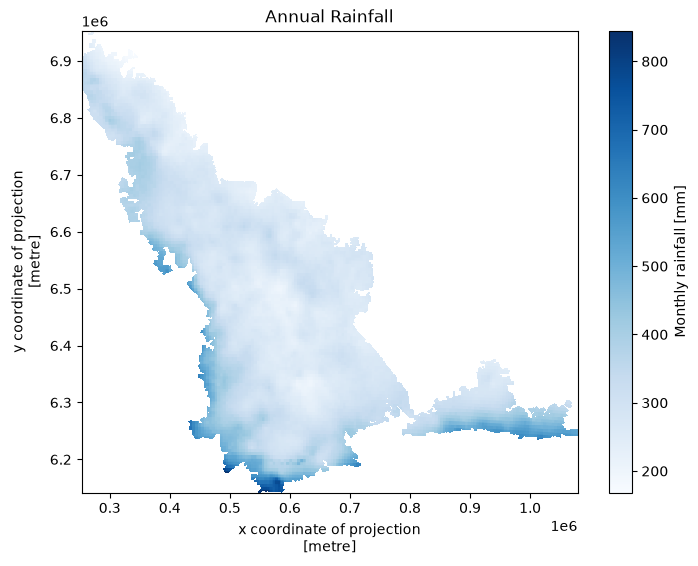

In [82]:
rain_small = rain_clip.coarsen(
    x=50,
    y=50,
    boundary="trim"
).mean()

plt.figure(figsize=(8,6))
rain_small.plot(cmap="Blues")
plt.title("Annual Rainfall")
plt.show()

In [83]:
from pathlib import Path

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data2" / "raw"

print(DATA_DIR)

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw


In [84]:
import rioxarray

dem = rioxarray.open_rasterio(
    DATA_DIR / "output_AW3D30.tif"
)

print(dem)

<xarray.DataArray (band: 1, y: 4061, x: 5470)> Size: 44MB
[22213670 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 32kB 31.99 31.99 31.99 31.99 ... 30.86 30.86 30.86
  * x            (x) float64 44kB 119.9 119.9 119.9 119.9 ... 121.5 121.5 121.5
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [85]:
print(PROCESSED_DIR)

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/processed


In [86]:
dem = rioxarray.open_rasterio(
    PROCESSED_DIR / "output_AW3D30_utm50s.tif"
)

print(dem)

<xarray.DataArray (band: 1, y: 4630, x: 5297)> Size: 49MB
[24525110 values with dtype=int16]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 37kB 1.355e+07 1.355e+07 ... 1.342e+07 1.342e+07
  * x            (x) float64 42kB 7.77e+05 7.77e+05 ... 9.257e+05 9.257e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [87]:
SLOPE_DIR = PROJECT_DIR / "data2" / "processed"

slope = rioxarray.open_rasterio(
    SLOPE_DIR / "slope.tif"
)

print(slope)

<xarray.DataArray (band: 1, y: 4630, x: 5297)> Size: 98MB
[24525110 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 37kB 1.355e+07 1.355e+07 ... 1.342e+07 1.342e+07
  * x            (x) float64 42kB 7.77e+05 7.77e+05 ... 9.257e+05 9.257e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0


In [88]:
salinity = gpd.read_file(
    PROCESSED_DIR / "salinity_wheatbelt.gpkg"
)

print(salinity.head())

  surf_sa_co                                             decode     id  \
0         L1  <3% of map unit has a moderate to extreme surf...  58754   
1         L1  <3% of map unit has a moderate to extreme surf...  58746   
2         L1  <3% of map unit has a moderate to extreme surf...  58767   
3         M2  30-50% of map unit has a moderate to extreme s...  58935   
4         M2  30-50% of map unit has a moderate to extreme s...  58934   

   st_area_shape_  st_perimeter_shape_  \
0        0.001699             0.262207   
1        0.000233             0.055026   
2        0.001192             0.204742   
3        0.000065             0.029482   
4        0.000106             0.042421   

                                            geometry  
0  MULTIPOLYGON (((118.18904 -34.67828, 118.19313...  
1  MULTIPOLYGON (((118.12608 -34.69076, 118.12734...  
2  MULTIPOLYGON (((118.15649 -34.62544, 118.15693...  
3  MULTIPOLYGON (((118.15029 -34.56029, 118.14984...  
4  MULTIPOLYGON (((118.1249

In [89]:
print("dem:", "✓" if "dem" in globals() else "✗")
print("slope:", "✓" if "slope" in globals() else "✗")
print("salinity:", "✓" if "salinity" in globals() else "✗")
print("rain_clip:", "✓" if "rain_clip" in globals() else "✗")
print("wheatbelt:", "✓" if "wheatbelt" in globals() else "✗")

dem: ✓
slope: ✓
salinity: ✓
rain_clip: ✓
wheatbelt: ✓


In [90]:
print(type(slope))
import rioxarray

slope = rioxarray.open_rasterio(
    PROCESSED_DIR / "slope.tif"
).squeeze()

print(type(slope))

<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>


In [91]:
import rioxarray

dem = rioxarray.open_rasterio("../data2/processed/cop30_utm50s.tif")
slope = rioxarray.open_rasterio("../data2/processed/slope_cop30.tif")

In [92]:

print("DEM")
print(dem.rio.shape)
print(dem.rio.resolution())

print("\nSlope")
print(slope.rio.shape)
print(slope.rio.resolution())

print("\nRain")
print(rain_clip.rio.shape)
print(rain_clip.rio.resolution())

DEM
(29816, 29553)
(28.431199796308288, -28.431199796308288)

Slope
(29816, 29553)
(28.431199796308288, -28.431199796308288)

Rain
(28595, 29057)
(28.431199796308288, -28.431199796308295)


In [93]:
print(dem.rio.crs)
print(rain_clip.rio.crs)
print(slope.rio.crs)


EPSG:32750
EPSG:32750
EPSG:32750


In [94]:
# 将 Rain 重投影到与 DEM 完全一致
rain_utm = rain_clip.rio.reproject_match(dem)

print(rain_utm.rio.crs)
print(rain_utm.rio.shape)
print(rain_utm.rio.resolution())

EPSG:32750
(29816, 29553)
(28.431199796308285, -28.431199796308277)


In [95]:
print("DEM")
print(dem.rio.crs)
print(dem.rio.shape)

print("\nSlope")
print(slope.rio.crs)
print(slope.rio.shape)

print("\nRain")
print(rain_utm.rio.crs)
print(rain_utm.rio.shape)

DEM
EPSG:32750
(29816, 29553)

Slope
EPSG:32750
(29816, 29553)

Rain
EPSG:32750
(29816, 29553)


In [96]:
# 特征工程（Feature Engineering）
# salinity_wheatbelt.gpkg 里面存的是我们要预测的"答案"
print(salinity.columns)
salinity.head()

Index(['surf_sa_co', 'decode', 'id', 'st_area_shape_', 'st_perimeter_shape_',
       'geometry'],
      dtype='str')


,surf_sa_co,decode,id,st_area_shape_,st_perimeter_shape_,geometry
0,L1,<3% of map unit has a moderate to extreme surf...,58754,0.001699,0.262207,"MULTIPOLYGON (((118.18904 -34.67828, 118.19313..."
1,L1,<3% of map unit has a moderate to extreme surf...,58746,0.000233,0.055026,"MULTIPOLYGON (((118.12608 -34.69076, 118.12734..."
2,L1,<3% of map unit has a moderate to extreme surf...,58767,0.001192,0.204742,"MULTIPOLYGON (((118.15649 -34.62544, 118.15693..."
3,M2,30-50% of map unit has a moderate to extreme s...,58935,0.000065,0.029482,"MULTIPOLYGON (((118.15029 -34.56029, 118.14984..."
4,M2,30-50% of map unit has a moderate to extreme s...,58934,0.000106,0.042421,"MULTIPOLYGON (((118.1249 -34.49811, 118.12497 ..."


In [97]:
# 方案一：多分类
print(salinity["surf_sa_co"].value_counts())

surf_sa_co
L1    4968
L2    3083
H1    1279
H2    1062
M1     881
M2     545
Name: count, dtype: int64


In [98]:
# 六分类（6-class Classification）
# 计算每个盐碱化 Polygon 的中心点
salinity["centroid"] = salinity.geometry.centroid

print(salinity[["surf_sa_co", "centroid"]].head())


  surf_sa_co                     centroid
0         L1  POINT (118.19339 -34.68006)
1         L1   POINT (118.1275 -34.69152)
2         L1  POINT (118.13829 -34.64192)
3         M2   POINT (118.15127 -34.5556)
4         M2  POINT (118.12499 -34.50452)


/var/folders/1h/1p8bcks947q878b7gn_8jhtm0000gn/T/ipykernel_1248/2718726235.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  salinity["centroid"] = salinity.geometry.centroid


In [99]:
print(salinity.crs)


EPSG:7844


In [100]:
salinity = salinity.to_crs(dem.rio.crs)

In [101]:
#提取中心点的坐标
salinity["x"] = salinity.centroid.x
salinity["y"] = salinity.centroid.y

salinity[["x", "y"]].head()


,x,y
0,609323.501637,6.161788e+06
1,603272.847667,6.160587e+06
2,604323.841168,6.166076e+06
3,605622.897924,6.175635e+06
4,603274.451832,6.181328e+06


In [102]:
print(type(dem))
print(type(slope))
print(type(rain_utm))
print(dem.dims)
print(slope.dims)
print(rain_utm.dims)

<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataarray.DataArray'>
('band', 'y', 'x')
('band', 'y', 'x')
('y', 'x')


In [105]:
print(rain_utm.dims)
print(annual_rain_proj.dims)

('y', 'x')
('y', 'x')


In [106]:
# 使用已经计算好的全年降雨
rain_mean = annual_rain_proj

# DEM 去掉 band 维度
dem = dem.squeeze()

print(dem.dims)
print(rain_mean.dims)

('y', 'x')
('y', 'x')


In [107]:
import numpy as np

def extract_values(raster, x_coords, y_coords):
    values = []

    for x, y in zip(x_coords, y_coords):
        value = raster.sel(
            x=x,
            y=y,
            method="nearest"
        ).values.item()

        values.append(value)

    return np.array(values)

# 提取 DEM
salinity["Elevation"] = extract_values(
    dem,
    salinity["x"],
    salinity["y"]
)


In [108]:
salinity.info()
salinity.describe()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 11818 entries, 0 to 11817
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   surf_sa_co           11818 non-null  str     
 1   decode               11818 non-null  str     
 2   id                   11818 non-null  int32   
 3   st_area_shape_       11818 non-null  float64 
 4   st_perimeter_shape_  11818 non-null  float64 
 5   geometry             11818 non-null  geometry
 6   centroid             11818 non-null  geometry
 7   x                    11818 non-null  float64 
 8   y                    11818 non-null  float64 
 9   Elevation            11818 non-null  float64 
dtypes: float64(5), geometry(2), int32(1), str(2)
memory usage: 877.2 KB


,id,st_area_shape_,st_perimeter_shape_,x,y,Elevation
count,11818.000000,1.181800e+04,11818.000000,1.181800e+04,1.181800e+04,11818.000000
mean,54718.376883,1.998083e-03,0.210933,5.767595e+05,6.408943e+06,283.373350
std,23150.058147,1.140560e-01,5.398712,1.373092e+05,1.401295e+05,75.633956
min,0.000000,6.648560e-09,0.000713,2.288360e+05,6.154696e+06,0.000000
25%,44510.250000,5.763182e-06,0.011388,4.984889e+05,6.298081e+06,248.000000
50%,56192.000000,2.951920e-05,0.028761,5.514366e+05,6.398769e+06,294.497192
75%,67674.250000,1.517272e-04,0.080004,6.234422e+05,6.465726e+06,333.745575
max,98557.000000,1.226213e+01,568.584252,1.065324e+06,6.913031e+06,466.843445


In [109]:
from pathlib import Path

RAW_DIR = Path("../data2/raw")

print(RAW_DIR.resolve())
print()

for f in RAW_DIR.iterdir():
    print(f.name)

/Users/wangjingxuan/Jingxuan_Wang/WA-Soil-Salinity-Prediction/data2/raw

cop30_wheatbelt.tif
output_AW3D30.tif
.DS_Store
output_hh 2.tif
output_hh.tif
Surface_Salinity_current_DPIRD_039_WA_GDA2020_Public.gpkg
2020.monthly_rain.nc
Wheatbelt_of_WA_DPIRD_024_WA_GDA2020_Public.gpkg


In [110]:
from pathlib import Path
import rasterio
from rasterio.merge import merge

RAW_DIR = Path("../data2/raw")

dem1 = rasterio.open(RAW_DIR / "output_hh.tif")
dem2 = rasterio.open(RAW_DIR / "output_hh 2.tif")

mosaic, transform = merge([dem1, dem2])

meta = dem1.meta.copy()
meta.update(
    height=mosaic.shape[1],
    width=mosaic.shape[2],
    transform=transform
)

output_file = RAW_DIR / "cop30_wheatbelt.tif"

with rasterio.open(output_file, "w", **meta) as dest:
    dest.write(mosaic)

dem1.close()
dem2.close()

print("完成：", output_file)

完成： ../data2/raw/cop30_wheatbelt.tif


In [111]:
import rioxarray

dem = rioxarray.open_rasterio(
    "../data2/raw/cop30_wheatbelt.tif"
)

print(dem)
print("CRS:", dem.rio.crs)
print("Bounds:", dem.rio.bounds())
print("Shape:", dem.shape)

<xarray.DataArray (band: 1, y: 27000, x: 30600)> Size: 3GB
[826200000 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 216kB -27.5 -27.5 -27.5 -27.5 ... -35.0 -35.0 -35.0
  * x            (x) float64 245kB 114.5 114.5 114.5 114.5 ... 123.0 123.0 123.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
CRS: EPSG:4326
Bounds: (114.4998611, -34.999861100000004, 122.99986109999999, -27.499861100000004)
Shape: (1, 27000, 30600)


In [112]:
from pathlib import Path

for f in Path("../data2/processed").glob("*.tif"):
    print(f.name)

output_AW3D30_utm50s.tif
slope_cop30.tif
slope.tif
cop30 utm50s.tif
cop30_utm50s.tif


In [113]:
import rasterio

src = rasterio.open("../data2/processed/cop30_utm50s.tif")

print(src.crs)
print(src.bounds)
print(src.shape)

EPSG:32750
BoundingBox(left=253009.1606663636, bottom=6110493.424922038, right=1093236.4082466625, top=6958198.078048766)
(29816, 29553)


In [115]:
print(annual_rain_proj)
print(rain_clip.rio.bounds())
print(dem.rio.bounds())
print(rain_clip.isnull().all().values)

<xarray.DataArray 'monthly_rain' (y: 29816, x: 29553)> Size: 7GB
array([[250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       [250.3, 250.3, 250.3, ..., 232.2, 232.2, 232.2],
       ...,
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ],
       [  0. ,   0. ,   0. , ...,   0. ,   0. ,   0. ]],
      shape=(29816, 29553))
Coordinates:
  * y            (y) float64 239kB 6.958e+06 6.958e+06 ... 6.111e+06 6.111e+06
  * x            (x) float64 236kB 2.53e+05 2.531e+05 ... 1.093e+06 1.093e+06
    spatial_ref  int64 8B 0
Attributes:
    long_name:   Monthly rainfall
    units:       mm
    valid_min:   -32765
    valid_max:   32767
    _FillValue:  nan
(253009.1606663636, 6140346.184708161, 1079134.5331476936, 6953336.342883597)
(114.4998611, -34.999861100000004, 122.99986109999999, -27.499861100000004)
False


In [120]:
print(type(slope))
salinity["Slope"] = [
    slope.sel(
        x=row.centroid.x,
        y=row.centroid.y,
        method="nearest"
    ).item()
    for _, row in salinity.iterrows()
]

<class 'xarray.core.dataarray.DataArray'>


In [121]:
salinity["Rain"] = [
    rain_clip.sel(
        x=row.centroid.x,
        y=row.centroid.y,
        method="nearest"
    ).item()
    for _, row in salinity.iterrows()
]

In [125]:
print(salinity.crs)

PROJCS["WGS 84 / UTM zone 50S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",117],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32750"]]


In [129]:
print(salinity[["x","y"]].head())

               x             y
0  609323.501637  6.161788e+06
1  603272.847667  6.160587e+06
2  604323.841168  6.166076e+06
3  605622.897924  6.175635e+06
4  603274.451832  6.181328e+06


In [130]:
salinity["Rain"] = [
    rain_clip.sel(
        x=row.x,
        y=row.y,
        method="nearest"
    ).item()
    for _, row in salinity.iterrows()
]

In [131]:
# 机器学习
# 检查有没有缺失值
salinity[["Elevation", "Slope", "Rain"]].isna().sum()

Elevation     0
Slope         0
Rain         36
dtype: int64

In [ ]:
# 删除那36个点
salinity = salinity.dropna(
    subset=["Rain"]
).reset_index(drop=True)

In [136]:
# 确认
salinity[["Elevation", "Slope", "Rain"]].isna().sum()

Elevation    0
Slope        0
Rain         0
dtype: int64

In [137]:
# 检查类别
print(salinity["surf_sa_co"].value_counts())

surf_sa_co
L1    4964
L2    3070
H1    1278
H2    1059
M1     869
M2     542
Name: count, dtype: int64
